In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler


In [3]:
# Load dataset
df = pd.read_csv(r"C:\Users\AI_LAB\Downloads\social_media_engagement_dataset.csv")

# Display first 5 rows
print("First 5 Rows")
print(df.head())

# Shape
print("\nDataset Shape:", df.shape)

First 5 Rows
    platform post_type  post_length   views  likes  comments  shares  \
0   Facebook      Text           62   91660   2968       276     346   
1  Instagram     Video          104  113115   4164       632     406   
2   Facebook     Video           46   36043   3125       188     100   
3   Facebook     Image           39  124886   5970       948     578   
4  Instagram     Video           42   82831   8212      1104     334   

   engagement_rate  
0         0.039166  
1         0.045989  
2         0.094692  
3         0.060023  
4         0.116502  

Dataset Shape: (10000, 8)


In [4]:
print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nColumn Names")
print(df.columns)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   platform         10000 non-null  object 
 1   post_type        10000 non-null  object 
 2   post_length      10000 non-null  int64  
 3   views            10000 non-null  int64  
 4   likes            10000 non-null  int64  
 5   comments         10000 non-null  int64  
 6   shares           10000 non-null  int64  
 7   engagement_rate  10000 non-null  float64
dtypes: float64(1), int64(5), object(2)
memory usage: 625.1+ KB
None

Statistical Summary
        post_length          views        likes      comments        shares  \
count  10000.000000   10000.000000  10000.00000  10000.000000  10000.000000   
mean      62.359800  127151.950600   7033.26920    879.232800    602.262700   
std       33.264888   75169.927932   5673.59828    812.409438    597.573391   
min   

In [5]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
platform           0
post_type          0
post_length        0
views              0
likes              0
comments           0
shares             0
engagement_rate    0
dtype: int64


In [6]:
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()


Duplicate Rows: 0


In [7]:
encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print("\nAfter Encoding")
print(df.head())


After Encoding
   platform  post_type  post_length   views  likes  comments  shares  \
0         0          1           62   91660   2968       276     346   
1         1          2          104  113115   4164       632     406   
2         0          2           46   36043   3125       188     100   
3         0          0           39  124886   5970       948     578   
4         1          2           42   82831   8212      1104     334   

   engagement_rate  
0         0.039166  
1         0.045989  
2         0.094692  
3         0.060023  
4         0.116502  


In [8]:
df.to_csv(r"C:\Users\AI_LAB\Downloads\social_media_preprocessed.csv", index=False)

print("\nPreprocessed dataset saved successfully.")


Preprocessed dataset saved successfully.


post_type
0    0.067147
1    0.066026
2    0.066903
Name: engagement_rate, dtype: float64


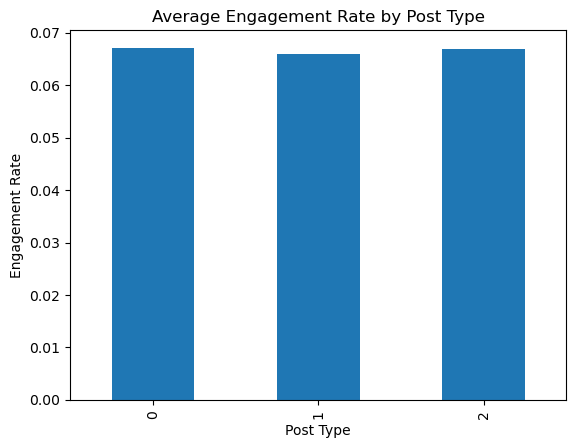

In [9]:
post_engagement = df.groupby("post_type")["engagement_rate"].mean()

print(post_engagement)

post_engagement.plot(kind='bar')

plt.title("Average Engagement Rate by Post Type")
plt.xlabel("Post Type")
plt.ylabel("Engagement Rate")
plt.show()

In [10]:
print("Average Views:", df["views"].mean())
print("Average Likes:", df["likes"].mean())
print("Average Comments:", df["comments"].mean())
print("Average Shares:", df["shares"].mean())

Average Views: 127151.9506
Average Likes: 7033.2692
Average Comments: 879.2328
Average Shares: 602.2627


In [11]:
correlation = df.corr()

print(correlation)

                 platform  post_type  post_length     views     likes  \
platform         1.000000  -0.000423    -0.023378 -0.148366 -0.112853   
post_type       -0.000423   1.000000     0.000199 -0.006033 -0.003177   
post_length     -0.023378   0.000199     1.000000  0.003489  0.007514   
views           -0.148366  -0.006033     0.003489  1.000000  0.740044   
likes           -0.112853  -0.003177     0.007514  0.740044  1.000000   
comments        -0.098586  -0.004100     0.010287  0.648297  0.877651   
shares          -0.093972   0.005172     0.007897  0.608048  0.825058   
engagement_rate -0.004871  -0.003216     0.000032  0.014413  0.584816   

                 comments    shares  engagement_rate  
platform        -0.098586 -0.093972        -0.004871  
post_type       -0.004100  0.005172        -0.003216  
post_length      0.010287  0.007897         0.000032  
views            0.648297  0.608048         0.014413  
likes            0.877651  0.825058         0.584816  
comments    

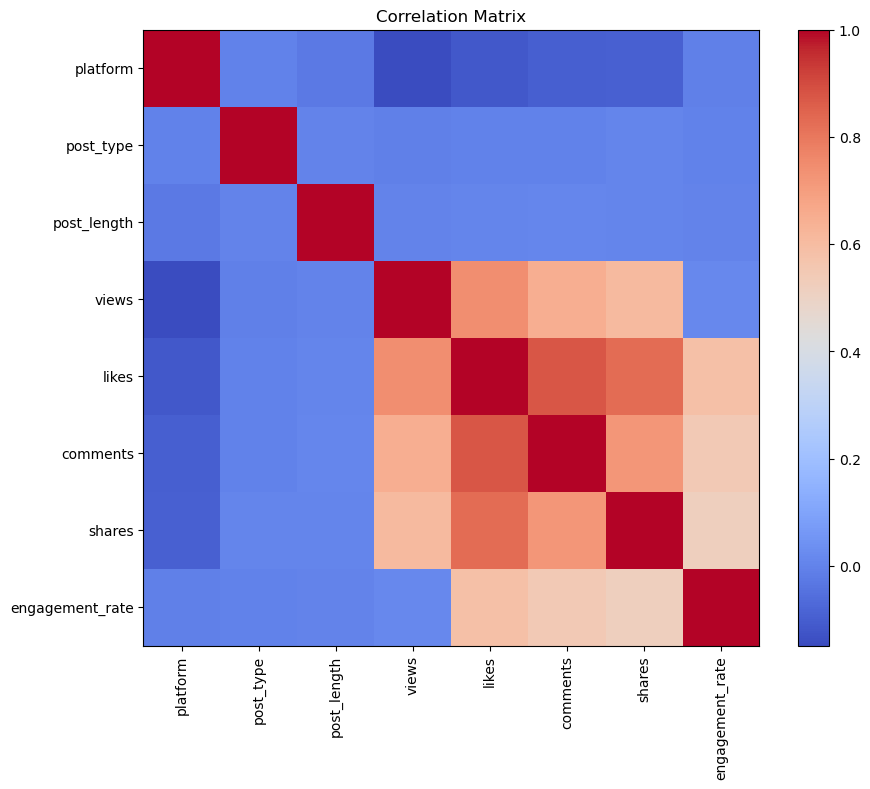

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(correlation, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()

1    3354
2    3347
0    3299
Name: platform, dtype: int64


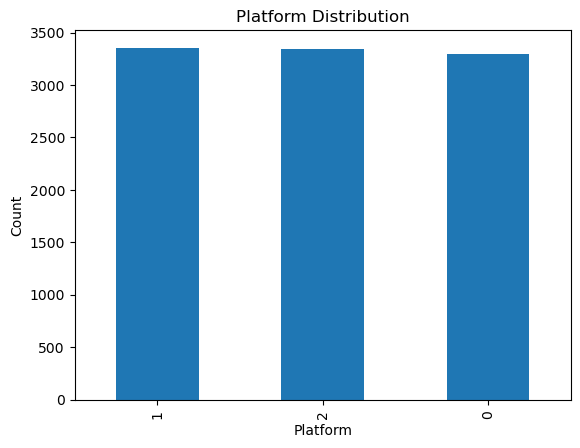

In [13]:
print(df["platform"].value_counts())

df["platform"].value_counts().plot(kind="bar")

plt.title("Platform Distribution")
plt.xlabel("Platform")
plt.ylabel("Count")

plt.show()

0    3370
2    3333
1    3297
Name: post_type, dtype: int64


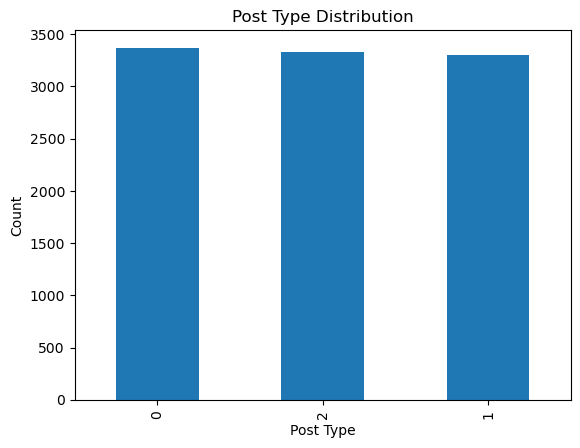

In [14]:
print(df["post_type"].value_counts())

df["post_type"].value_counts().plot(kind="bar")

plt.title("Post Type Distribution")
plt.xlabel("Post Type")
plt.ylabel("Count")

plt.show()

In [15]:
df.to_csv(r"C:\Users\AI_LAB\Downloads\Final_SocialMedia_Dataset.csv", index=False)

print("CRISP-DM preprocessing completed successfully.")

CRISP-DM preprocessing completed successfully.
